In [ ]:
from datetime import datetime
import pandas as pd
from matplotlib import pyplot as plt
import pycountry
from os import listdir as ls
import numpy as np
import arviz as az
from IPython.display import display, Markdown
import pycountry_convert as pc
from matplotlib_inline.backend_inline import set_matplotlib_formats

from emu_renewal.constants import OUTPUTS_PATH, DATA_PATH, MOB_LOCATION_SOURCE_MAP, MOB_LOCATION_NAME_MAP, MOBILITY_SMOOTH_PERIOD, G_MOB_LOCATION_CMAP
from emu_renewal.plotting import compare_proc_mob, CONT_CMAP, get_standard_subplot, compare_proc_weighted_gmob
from emu_renewal.utils import get_countries_by_continent
from emu_renewal.selection import get_mob_avail_countries
from emu_renewal.inputs import get_google_mobility, get_world_shp

set_matplotlib_formats("svg")

In [ ]:
job_path = OUTPUTS_PATH / "46622452"
all_countries = ls(job_path)
countries_by_cont = get_countries_by_continent(all_countries)
notes = {
    "g_mob": "Mobility values presented as Google data divided by 100, plus one.",
    "fb_visited_mob": "Mobility values presented as one plus Facebook data.",
    "fb_singletile_mob": "Mobility values presented as one minus Facebook data.",
}

# Purpose
This document presents the results of the variable process (with uncertainty)
implemented without scaling for mobility for each country.
It is intended to provide a raw comparison between the 
residual non-mechanistic variable process that needed
to be applied for each analysis in the absence of mobility scaling
and the various mobility data fields available from both Google and Facebook.

# Results by continent and country

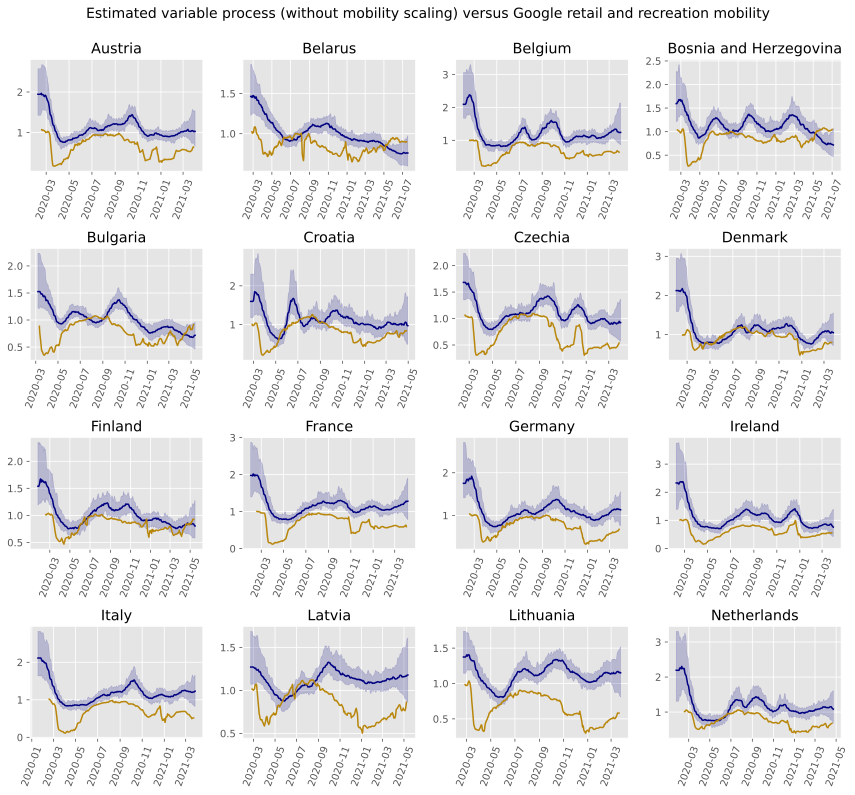

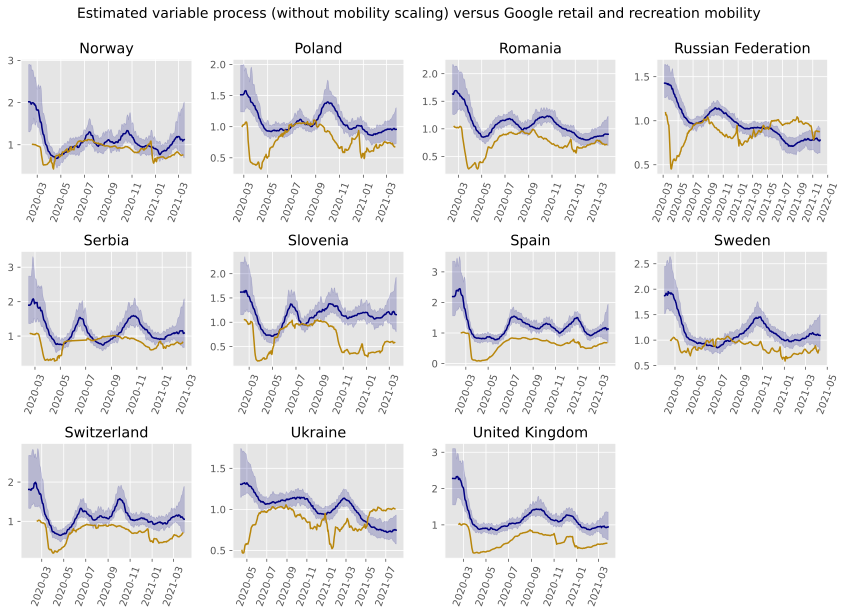

### North America

In [ ]:
for cont in CONT_CMAP:
    n_cols = 3 if cont in ["NA", "SA"] else 4
    _, _, mob_avail_countries, _ = get_mob_avail_countries()
    section_title = f"## Composite Google mobility comparison\n\n"
    display(Markdown(section_title))
    countries = [c for c in countries_by_cont[cont] if c in mob_avail_countries]
    if cont == "EU":
        display(compare_proc_weighted_gmob(job_path, countries[:16], 50, n_cols))
        display(compare_proc_weighted_gmob(job_path, countries[16:], 50, n_cols))
    else:
        display(compare_proc_weighted_gmob(job_path, countries, 50, n_cols))
                    
for mob_type in MOB_LOCATION_SOURCE_MAP:
    mob_source = MOB_LOCATION_SOURCE_MAP[mob_type]
    mob_name = MOB_LOCATION_NAME_MAP[mob_type]
    mob_type_text = mob_type.replace("_", " ")
    section_title = f"## {mob_name} mobility metric comparison\n\n"
    display(Markdown(section_title))
    display(Markdown(notes[mob_source]))
    for cont in CONT_CMAP:
        _, _, g_avail, fb_avail = get_mob_avail_countries()
        mob_avail_countries = g_avail if mob_source == "g_mob" else fb_avail
        countries = [c for c in countries_by_cont[cont] if c in mob_avail_countries]
        display(Markdown(f"### {pc.convert_continent_code_to_continent_name(cont)}"))
        n_cols = 3 if cont in ["NA", "SA"] else 4
        if cont == "EU":
            display(compare_proc_mob(job_path, countries[:16], n_cols, mob_type))
            display(compare_proc_mob(job_path, countries[16:], n_cols, mob_type))
        else:

            display(compare_proc_mob(job_path, countries, n_cols, mob_type))